In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
from pathlib import Path
from stop_words import get_stop_words
from sentence_transformers import SentenceTransformer
from sklearn.neighbors import NearestNeighbors

INPUT_FILE = '../prompt_iteration/v6_samples.csv'

df = pd.read_csv(INPUT_FILE)
print(df['class_label'].value_counts())
df.head()
yes = df[df['class_label'] == 'Yes']['Text']
no  = df[df['class_label'] == 'No']['Text']

class_label
Yes    4096
No     4096
Name: count, dtype: int64


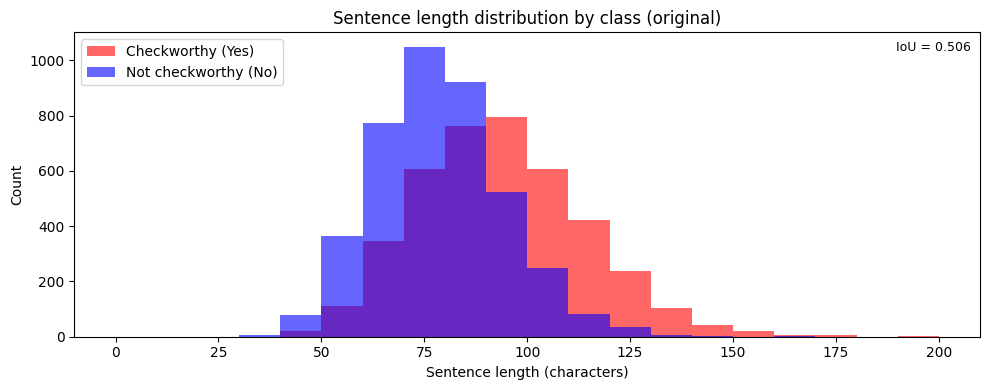

In [18]:
def plot_length_hist(yes_ser, no_ser, title='Sentence length distribution by class'):
    yes_lengths = yes_ser.str.len()
    no_lengths  = no_ser.str.len()
    bins = list(range(0, max(yes_lengths.max(), no_lengths.max()) + 10, 10))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(yes_lengths, bins=bins, alpha=0.6, label='Checkworthy (Yes)', color='red')
    ax.hist(no_lengths,  bins=bins, alpha=0.6, label='Not checkworthy (No)', color='blue')

    yes_counts, _ = np.histogram(yes_lengths, bins=bins)
    no_counts,  _ = np.histogram(no_lengths,  bins=bins)
    iou = np.minimum(yes_counts, no_counts).sum() / np.maximum(yes_counts, no_counts).sum()
    ax.text(0.99, 0.97, f'IoU = {iou:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9)

    ax.set_xlabel('Sentence length (characters)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_length_hist(yes, no, 'Sentence length distribution by class (original)')

Balanced sizes — Yes: 3425, No: 3424


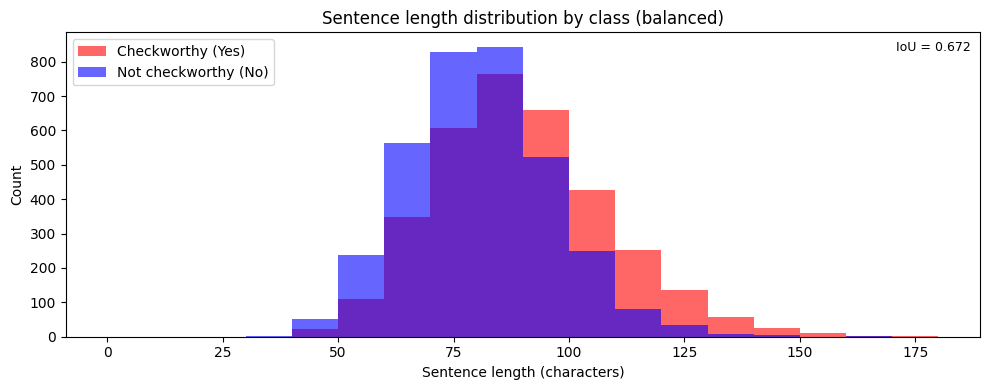

In [19]:
BIN_SIZE = 10

def balance_by_length(yes_ser, no_ser, alpha=1.0, bin_size=BIN_SIZE, seed=42):
    """
    alpha=1.0 → full balance (min count per bin)
    alpha=0.0 → no removal (keep all)
    Preserves original df index.
    """
    rng = np.random.default_rng(seed)
    yes_df = yes_ser.to_frame()
    no_df  = no_ser.to_frame()

    # Assign each sample to a length bin (floored to nearest bin_size)
    yes_df['_bin'] = (yes_df['Text'].str.len() // bin_size) * bin_size
    no_df['_bin']  = (no_df['Text'].str.len()  // bin_size) * bin_size

    all_bins = set(yes_df['_bin']) | set(no_df['_bin'])
    yes_kept, no_kept = [], []
    for b in all_bins:
        y = yes_df[yes_df['_bin'] == b].index.tolist()
        n = no_df[no_df['_bin'] == b].index.tolist()
        min_count = min(len(y), len(n))
        # Interpolate target between actual count (alpha=0) and min count (alpha=1)
        y_target = round((1 - alpha) * len(y) + alpha * min_count)
        n_target = round((1 - alpha) * len(n) + alpha * min_count)
        if y_target > 0:
            yes_kept.extend(rng.choice(y, y_target, replace=False))
        if n_target > 0:
            no_kept.extend(rng.choice(n, n_target, replace=False))

    return yes_df.loc[yes_kept, 'Text'], no_df.loc[no_kept, 'Text']

yes, no = balance_by_length(yes, no, alpha=0.5)
print(f"Balanced sizes — Yes: {len(yes)}, No: {len(no)}")
plot_length_hist(yes, no, 'Sentence length distribution by class (balanced)')

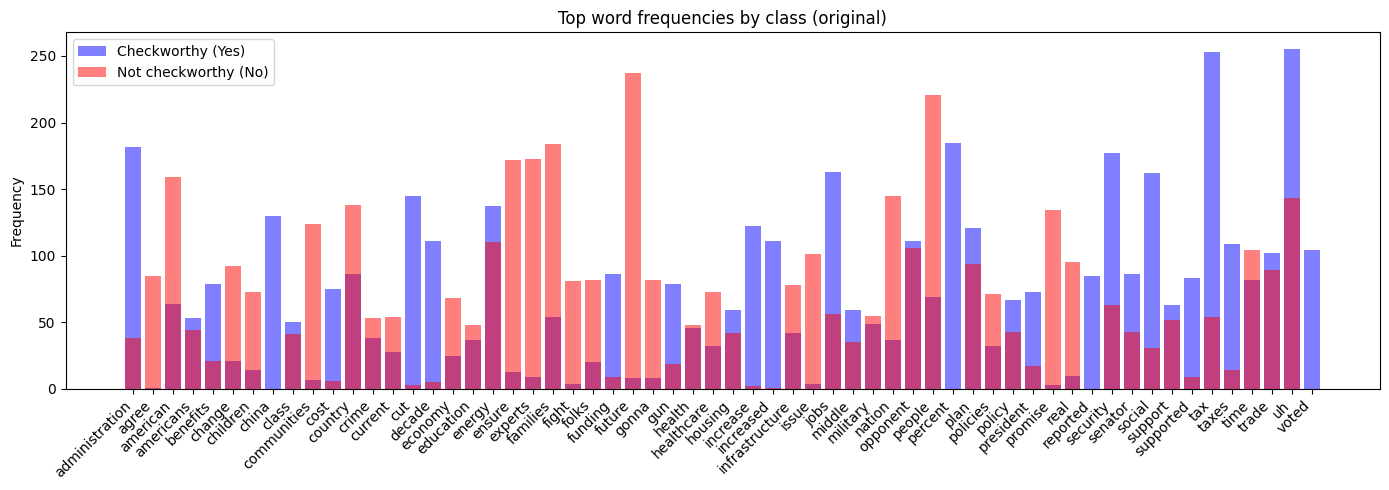

In [20]:
STOPWORDS = set(get_stop_words('en'))

def plot_word_freq(yes_ser, no_ser, top_n=30, title='Top word frequencies by class (stopwords removed)'):
    def count_words(series):
        words = re.findall(r'[a-z]+', ' '.join(series).lower())
        return Counter(w for w in words if w not in STOPWORDS)

    yes_wc = count_words(yes_ser)
    no_wc  = count_words(no_ser)

    # Shared vocabulary: top-N by combined frequency
    combined = yes_wc + no_wc
    all_words = sorted(w for w, _ in combined.most_common(top_n))

    x = range(len(all_words))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x, [yes_wc.get(w, 0) for w in all_words], alpha=0.5, label='Checkworthy (Yes)', color='blue')
    ax.bar(x, [no_wc.get(w, 0)  for w in all_words], alpha=0.5, label='Not checkworthy (No)', color='red')
    ax.set_xticks(list(x))
    ax.set_xticklabels(all_words, rotation=45, ha='right')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_word_freq(yes, no, top_n=60, title='Top word frequencies by class (original)')

Word-balanced sizes — Yes: 2569, No: 2576


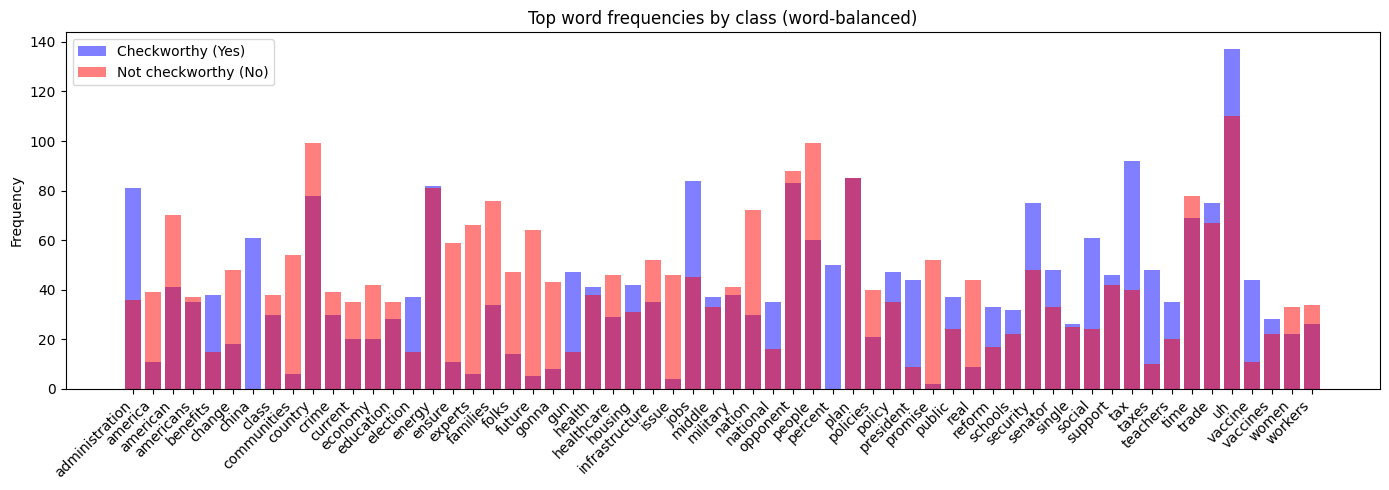

In [21]:
def balance_by_words(yes_ser, no_ser, alpha=1.0, batch_size=10):
    """
    Iteratively removes the most class-distinctive samples in small batches,
    recomputing word excess after each batch so removal doesn't overshoot.

    alpha     → fraction of initially-excess-contributing samples to remove
    batch_size → samples removed per class per iteration before recomputing excess
    Returns series with original df index preserved.
    """
    def tokenize(text):
        return [w for w in re.findall(r'[a-z]+', text.lower()) if w not in STOPWORDS]

    # Precompute tokenizations once for speed
    yes_tokens = {i: tokenize(t) for i, t in yes_ser.items()}
    no_tokens  = {i: tokenize(t) for i, t in no_ser.items()}

    def compute_excess(yes_ids, no_ids):
        """Per-word excess for each class given the current sample sets."""
        yes_wc = Counter(w for i in yes_ids for w in yes_tokens[i])
        no_wc  = Counter(w for i in no_ids  for w in no_tokens[i])
        all_words = set(yes_wc) | set(no_wc)
        return (
            {w: max(0, yes_wc[w] - no_wc.get(w, 0)) for w in all_words},
            {w: max(0, no_wc[w]  - yes_wc.get(w, 0)) for w in all_words},
        )

    def score(ids, tokens, excess):
        """Distinctiveness score per sample: sum of excess values of its words."""
        return np.array([sum(excess.get(w, 0) for w in tokens[i]) for i in ids])

    def remove_top_k(ids, scores, k):
        """Remove the k highest-scoring ids and return the rest."""
        remove_set = set(np.argsort(-scores)[:k].tolist())
        return [id_ for i, id_ in enumerate(ids) if i not in remove_set]

    yes_ids = list(yes_ser.index)
    no_ids  = list(no_ser.index)

    # Fix removal budget from the original distribution so alpha is interpretable
    yes_exc0, no_exc0 = compute_excess(yes_ids, no_ids)
    n_yes_budget = round(alpha * (score(yes_ids, yes_tokens, yes_exc0) > 0).sum())
    n_no_budget  = round(alpha * (score(no_ids,  no_tokens,  no_exc0)  > 0).sum())

    yes_removed = no_removed = 0
    while yes_removed < n_yes_budget or no_removed < n_no_budget:
        # Recompute excess with whatever samples remain
        yes_exc, no_exc = compute_excess(yes_ids, no_ids)

        if yes_removed < n_yes_budget:
            s = score(yes_ids, yes_tokens, yes_exc)
            if (s > 0).sum() == 0:
                break  # no excess left in yes class — stop early
            k = min(batch_size, n_yes_budget - yes_removed)
            yes_ids = remove_top_k(yes_ids, s, k)
            yes_removed += k

        if no_removed < n_no_budget:
            s = score(no_ids, no_tokens, no_exc)
            if (s > 0).sum() == 0:
                break  # no excess left in no class — stop early
            k = min(batch_size, n_no_budget - no_removed)
            no_ids = remove_top_k(no_ids, s, k)
            no_removed += k

    return yes_ser.loc[yes_ids], no_ser.loc[no_ids]

yes_wbal, no_wbal = balance_by_words(yes, no, alpha=0.25)
print(f"Word-balanced sizes — Yes: {len(yes_wbal)}, No: {len(no_wbal)}")
plot_word_freq(yes_wbal, no_wbal, top_n=60, title='Top word frequencies by class (word-balanced)')

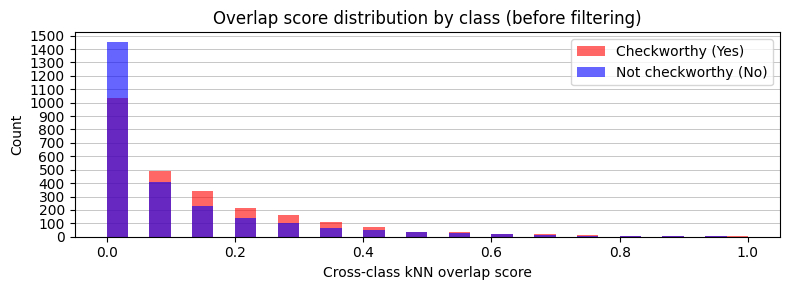

In [22]:
def compute_overlap_scores(yes_ser, no_ser, k=15, model_name='all-MiniLM-L6-v2'):
    """Embed all samples and compute per-sample cross-class kNN overlap scores."""
    all_texts  = pd.concat([yes_ser, no_ser])
    all_labels = np.array([1] * len(yes_ser) + [0] * len(no_ser))
    encoder    = SentenceTransformer(model_name)
    embeddings = encoder.encode(all_texts.tolist(), show_progress_bar=False, batch_size=64)
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(embeddings)
    _, indices = nbrs.kneighbors(embeddings)
    scores = np.array([
        (all_labels[indices[i, 1:]] != all_labels[i]).mean()
        for i in range(len(embeddings))
    ])
    return scores, all_labels


def plot_overlap_scores(yes_ser, no_ser, k=15, title='Overlap score distribution by class'):
    scores, labels = compute_overlap_scores(yes_ser, no_ser, k=k)
    bins = np.linspace(scores.min(), scores.max(), 31)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(scores[labels == 1], bins=bins, alpha=0.6, label='Checkworthy (Yes)', color='red')
    ax.hist(scores[labels == 0], bins=bins, alpha=0.6, label='Not checkworthy (No)', color='blue')
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=16, integer=True))
    ax.grid(axis='y', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.set_xlabel('Cross-class kNN overlap score')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def filter_by_overlap(yes_ser, no_ser, alpha=0.5, k=15, model_name='all-MiniLM-L6-v2'):
    """
    Drops the alpha-fraction of each class with the lowest cross-class kNN overlap score.

    alpha=0.0 → keep all
    alpha=0.5 → drop the 50% most class-pure samples from each class
    """
    scores, labels = compute_overlap_scores(yes_ser, no_ser, k=k, model_name=model_name)
    yes_global = np.where(labels == 1)[0]
    no_global  = np.where(labels == 0)[0]

    def keep_top(global_idx, orig_ser):
        s      = scores[global_idx]
        n_keep = len(global_idx) - round(alpha * len(global_idx))
        return orig_ser.iloc[np.sort(np.argsort(-s)[:n_keep])]

    return keep_top(yes_global, yes_ser), keep_top(no_global, no_ser)


plot_overlap_scores(yes_wbal, no_wbal, title='Overlap score distribution by class (before filtering)')

After embedding filter — Yes: 2055, No: 2061


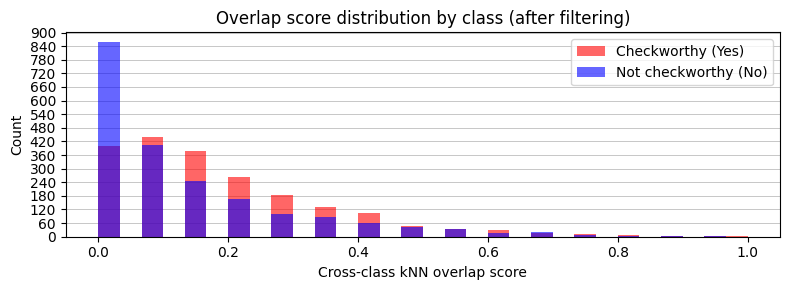

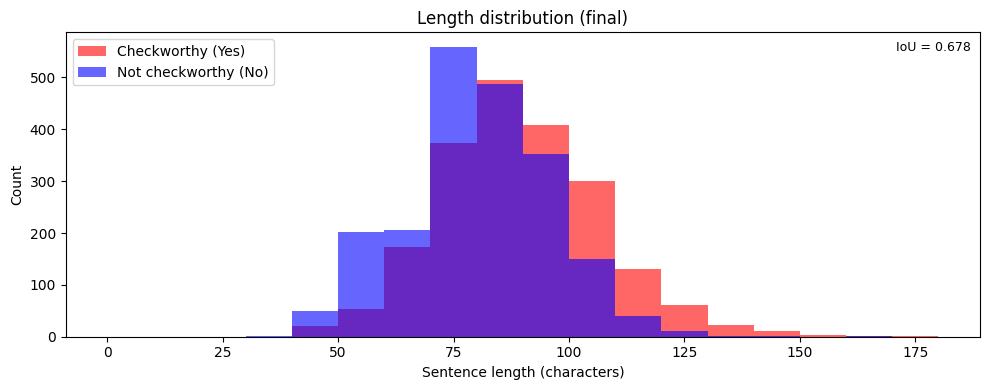

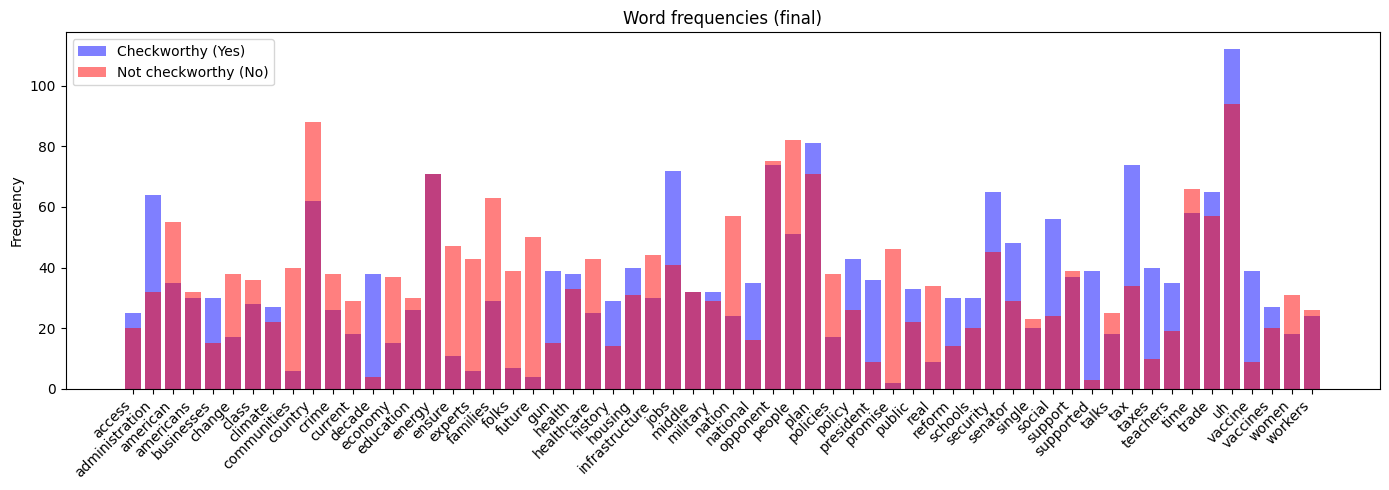

In [23]:
yes_ovbal, no_ovbal = filter_by_overlap(yes_wbal, no_wbal, alpha=0.2)
print(f"After embedding filter — Yes: {len(yes_ovbal)}, No: {len(no_ovbal)}")

plot_overlap_scores(yes_ovbal, no_ovbal, title='Overlap score distribution by class (after filtering)')
plot_length_hist(yes_ovbal, no_ovbal, 'Length distribution (final)')
plot_word_freq(yes_ovbal, no_ovbal, top_n=60, title='Word frequencies (final)')

In [24]:
output_csv = Path(INPUT_FILE).stem + '_filtered.csv'

# Restore perfect class balance by truncating the larger class
n = min(len(yes_ovbal), len(no_ovbal))
yes_final = yes_ovbal.sample(n, random_state=42)
no_final  = no_ovbal.sample(n, random_state=42)

kept_idx    = yes_final.index.union(no_final.index)
df_filtered = df.loc[kept_idx].copy()
df_filtered.to_csv(output_csv, index=False)
print(f"Saved {len(df_filtered)} rows to {output_csv}")
print(df_filtered['class_label'].value_counts())

Saved 4110 rows to v6_samples_filtered.csv
class_label
Yes    2055
No     2055
Name: count, dtype: int64
